Given a binary search tree (BST) where all node values are unique, and two nodes from the tree p and q, return the lowest common ancestor (LCA) of the two nodes.

The lowest common ancestor between two nodes p and q is the lowest node in a tree T such that both p and q as descendants. The ancestor is allowed to be a descendant of itself.

Example 1:

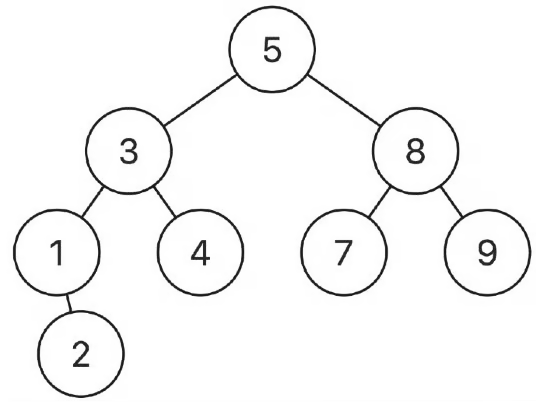

Input: root = [5,3,8,1,4,7,9,null,2], p = 3, q = 8

Output: 5

Example 2:

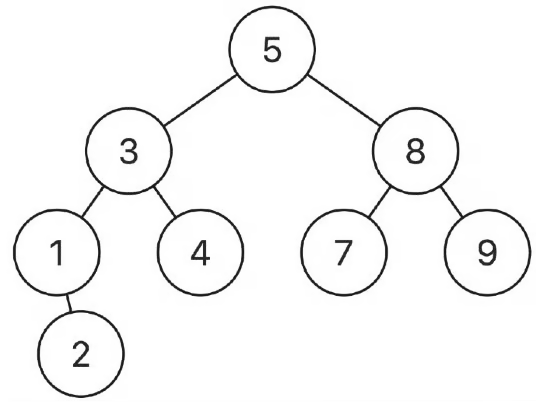

Input: root = [5,3,8,1,4,7,9,null,2], p = 3, q = 4

Output: 3

Explanation: The LCA of nodes 3 and 4 is 3, since a node can be a descendant of itself.

In [ ]:
# Definition for a binary tree node.
class TreeNode:
    def __init__(self, val=0, left=None, right=None):
        self.val = val
        self.left = left
        self.right = right

# Time Complexity: O(h)
# Space Complexity: O(h)
class Solution:
    def lowestCommonAncestor(self, root: TreeNode, p: TreeNode, q: TreeNode) -> TreeNode:
        if root is None:
            return None
        if root.val == p.val or root.val == q.val:
            return root
        left = self.lowestCommonAncestor(root.left, p, q)
        right = self.lowestCommonAncestor(root.right, p, q)
        if left and right:
            return root
        return left if left else right

# Recursion

Intuition

We are working with a Binary Search Tree (BST), so:

All values in the left subtree of a node are smaller than the node’s value.

All values in the right subtree are greater than the node’s value.

For two nodes p and q:

If both values are smaller than the current node -> both must lie in the left subtree.

If both values are greater than the current node -> both must lie in the right subtree.

Otherwise, the current node is the split point where one node is on the left and the other is on the right (or one is equal to the current node).

That split point is the Lowest Common Ancestor (LCA).

Algorithm

Start from the root.

While at a node:

If both p and q have values less than the current node's value:

Move to the left child.

Else if both p and q have values greater than the current node's value:

Move to the right child.

Otherwise:

The current node is the LCA -> return it.

If the tree is empty, return null.

In [ ]:
# Time Complexity: O(h)
# Space Complexity: O(h)
class Solution:
    def lowestCommonAncestor(self, root: TreeNode, p: TreeNode, q: TreeNode) -> TreeNode:
        # if not root or not p or not q:
        #     return None
        if (max(p.val, q.val) < root.val):
            return self.lowestCommonAncestor(root.left, p, q)
        elif (min(p.val, q.val) > root.val):
            return self.lowestCommonAncestor(root.right, p, q)
        else:
            return root

# Iteration

Intuition

This is the iterative version of finding the Lowest Common Ancestor (LCA) in a Binary Search Tree (BST).

Because a BST is ordered:

Left subtree < node < right subtree

We can decide where both nodes lie just by comparing values.

If p and q are both greater than the current node -> move right.

If they are both smaller -> move left.

If they split (one on each side) or one equals the current node ->
current node is the LCA, because it's the first node where their paths diverge.

This avoids recursion and simply walks down the tree until the split point is found.

Algorithm

Set cur = root.

While cur is not null:

If p.val and q.val are both greater than cur.val -> go right.

Else if both are smaller -> go left.

Otherwise:

You've found the first node where their paths separate -> return cur (the LCA).

Return null if tree is empty (should not happen for valid input).

In [ ]:
# Time Complexity: O(h)
# Space Complexity: O(1)
class Solution:
    def lowestCommonAncestor(self, root: TreeNode, p: TreeNode, q: TreeNode) -> TreeNode:
        cur = root

        while cur:
            if p.val > cur.val and q.val > cur.val:
                cur = cur.right
            elif p.val < cur.val and q.val < cur.val:
                cur = cur.left
            else:
                return cur